# Classificação e Operações com Funções

**Módulo:** 01 – Conjuntos e Funções

**Pré-requisitos:** [`0105a_funcoes.ipynb`](0105a_funcoes.ipynb) (conceito, notação, domínio/contradomínio/imagem, gráfico no plano cartesiano, funções iguais)

**Objetivos de aprendizagem:**
- Classificar uma função como crescente, decrescente ou constante em um intervalo.
- Identificar funções pares e ímpares e reconhecer a simetria correspondente no gráfico.
- Classificar uma função quanto à correspondência entre domínio e contradomínio (injetora, sobrejetora, bijetora).
- Operar com funções (soma, diferença, produto, quociente e composição) e determinar a inversa de uma função bijetora.

**Tempo estimado:** 55 a 70 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/01_conjuntos_e_funcoes/0106a_classificacao_e_operacoes_com_funcoes.ipynb)

## A temperatura ao longo do dia

Pense na temperatura de uma cidade ao longo de um dia comum: de manhã cedo ela **sobe** conforme o sol esquenta; no meio da tarde ela costuma **ficar estável** por um tempo; à noite, com o sol se pondo, ela **cai** de novo.

Qualquer pessoa reconhece esse comportamento olhando para um gráfico. Mas e se você precisasse **descrever isso matematicamente**, sem apontar para o gráfico e dizer "olha, sobe aqui, fica reto ali, desce depois"? É exatamente essa linguagem — precisa, sem depender de apontar — que vamos construir neste notebook.

## Função crescente, decrescente e constante

- 📌 **Definição formal:** sejam x1 e x2 dois valores do domínio de f, com x1 < x2. Dizemos que f é:
    - **crescente** nesse trecho se f(x1) < f(x2);
    - **decrescente** nesse trecho se f(x1) > f(x2);
    - **constante** nesse trecho se f(x1) = f(x2).
- Leitura direta no gráfico: "sobe da esquerda para a direita" (crescente), "desce da esquerda para a direita" (decrescente), "fica na horizontal" (constante).

Mexa nos sliders x1 e x2 abaixo e observe onde cada ponto cai sobre a curva de temperatura do gancho. O notebook mostra a fórmula, o gráfico e uma tabela de valores — as três representações do mesmo comportamento.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"


def estilizar_eixo(ax) -> None:
    '''Aplica o estilo Nord padrão a um eixo do matplotlib.'''
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)


def temperatura(x):
    '''Temperatura (C) ao longo de um dia, de x=0 (6h) a x=14 (20h).

    Sobe pela manhã (x<4), fica estável à tarde (4<=x<8), cai à noite (x>=8).
    '''
    x = np.asarray(x, dtype=float)
    return np.where(
        x < 4, 15 + 2 * x,
        np.where(x < 8, 23, 23 - 1.5 * (x - 8)),
    )


xs_temp = np.linspace(0, 14, 400)


def explorar_crescimento(x1: float, x2: float) -> None:
    y1, y2 = float(temperatura(x1)), float(temperatura(x2))
    menor, maior = (x1, x2) if x1 <= x2 else (x2, x1)

    fig, ax = plt.subplots(figsize=(7, 4.3))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs_temp, temperatura(xs_temp), color=COR_DESTAQUE, linewidth=2.2, zorder=1)
    ax.scatter([x1], [y1], s=110, color=COR_PONTO, zorder=3, label=f"x1 = {x1:g}")
    ax.scatter([x2], [y2], s=110, color=COR_SECUNDARIA, zorder=3, label=f"x2 = {x2:g}")
    ax.set_xlabel("horas desde as 6h", color=NORD_TEXTO_SEC)
    ax.set_ylabel("temperatura (°C)", color=NORD_TEXTO_SEC)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=9)
    plt.show()

    if y1 < y2:
        comparacao = "f(x1) < f(x2)  ->  trecho crescente entre x1 e x2"
    elif y1 > y2:
        comparacao = "f(x1) > f(x2)  ->  trecho decrescente entre x1 e x2"
    else:
        comparacao = "f(x1) = f(x2)  ->  trecho constante (ou mesmo x)"

    print(f"Fórmula: temperatura(x), por partes (ver definição acima)")
    print(f"f(x1) = f({x1:g}) = {y1:g}")
    print(f"f(x2) = f({x2:g}) = {y2:g}")
    print(f"Comparação: {comparacao}")

    tabela = pd.DataFrame({"x": np.round(np.linspace(menor, maior, 5), 2)})
    tabela["f(x)"] = np.round(temperatura(tabela["x"]), 2)
    display(tabela)


widgets.interact(
    explorar_crescimento,
    x1=widgets.FloatSlider(value=2.0, min=0, max=14, step=0.5, description="x1:"),
    x2=widgets.FloatSlider(value=10.0, min=0, max=14, step=0.5, description="x2:"),
)

interactive(children=(FloatSlider(value=2.0, description='x1:', max=14.0, step=0.5), FloatSlider(value=10.0, d…

<function __main__.explorar_crescimento(x1: float, x2: float) -> None>

## Taxa de variação / análise por intervalos

- Repare que a mesma função pode crescer num trecho do domínio e decrescer em outro — a classificação crescente/decrescente é sempre **por intervalo**, raramente vale para o domínio inteiro (a temperatura do exemplo cresce, depois fica constante, depois decresce — tudo na mesma função).
- Ao olhar um gráfico, o primeiro passo é identificar visualmente os intervalos onde a curva sobe, onde fica reta e onde desce.
- 📌 **Conexão:** essa ideia de "onde a função cresce e onde decresce" prepara terreno para **máximos e mínimos**, que vão aparecer com força em Cálculo (módulo 11).

**Perguntas de checagem:**
1. Uma função pode ser crescente em um trecho e decrescente em outro? Dê um exemplo do dia a dia.
2. O que significa uma função ser constante em um intervalo?

## Função par e função ímpar

- 📌 **Definição formal:**
    - f é **par** se f(-x) = f(x) para todo x do domínio — o gráfico é simétrico em relação ao **eixo y**.
    - f é **ímpar** se f(-x) = -f(x) para todo x do domínio — o gráfico é simétrico em relação à **origem**.
- Em ambos os casos, a definição precisa valer para **todo** x do domínio, não só para alguns valores.

Mova o slider x e observe o ponto (x, f(x)) e seu espelhado (-x, f(-x)) nos dois gráficos abaixo — um de função par, outro de função ímpar.

In [ ]:
def funcao_par(x):
    return x**2


def funcao_impar(x):
    return x**3


xs_sim = np.linspace(-3, 3, 400)


def explorar_simetria(x: float) -> None:
    fig, (eixo_par, eixo_impar) = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)

    casos = [
        (eixo_par, funcao_par, "f(x) = x²  (par)"),
        (eixo_impar, funcao_impar, "f(x) = x³  (ímpar)"),
    ]
    for eixo, f, nome in casos:
        estilizar_eixo(eixo)
        eixo.plot(xs_sim, f(xs_sim), color=COR_DESTAQUE, linewidth=2.2, zorder=1)
        eixo.axhline(0, color=NORD_LINHA, linewidth=0.8, zorder=0)
        eixo.axvline(0, color=NORD_LINHA, linewidth=0.8, zorder=0)
        eixo.scatter([x], [f(x)], s=120, color=COR_PONTO, zorder=3, label=f"({x:g}, {f(x):g})")
        eixo.scatter([-x], [f(-x)], s=120, color=COR_ALERTA, zorder=3, label=f"({-x:g}, {f(-x):g})")
        eixo.plot([x, -x], [f(x), f(-x)], color=NORD_TEXTO_SEC, linewidth=1, linestyle=":", zorder=2)
        eixo.set_title(nome, color=NORD_TEXTO, fontsize=10.5)
        eixo.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8.5)

    plt.tight_layout()
    plt.show()

    print(f"x = {x:g}")
    print(f"funcao_par:   f({x:g}) = {funcao_par(x):g}   f({-x:g}) = {funcao_par(-x):g}   (iguais -> par)")
    print(f"funcao_impar: f({x:g}) = {funcao_impar(x):g}   f({-x:g}) = {funcao_impar(-x):g}   (opostos -> ímpar)")


widgets.interact(
    explorar_simetria,
    x=widgets.FloatSlider(value=1.5, min=0.25, max=3, step=0.25, description="x:"),
)

interactive(children=(FloatSlider(value=1.5, description='x:', max=3.0, min=0.25, step=0.25), Output()), _dom_…

<function __main__.explorar_simetria(x: float) -> None>

## Nem toda função é par nem ímpar

- ⚠️ **Erro comum:** achar que toda função tem que ser par ou ímpar. A maioria das funções **não é** nem uma coisa nem outra — par e ímpar são casos particulares, não uma classificação obrigatória.
- Para provar que uma função **não** é par nem ímpar, basta um único contraexemplo: um valor de x onde f(-x) ≠ f(x) **e** f(-x) ≠ -f(x).

In [3]:
def eh_par(f, amostras=(1, 2, 3, 5)) -> bool:
    '''Verifica numericamente se f(-x) = f(x) para um conjunto de amostras de x.'''
    return all(np.isclose(f(-a), f(a)) for a in amostras)


def eh_impar(f, amostras=(1, 2, 3, 5)) -> bool:
    '''Verifica numericamente se f(-x) = -f(x) para um conjunto de amostras de x.'''
    return all(np.isclose(f(-a), -f(a)) for a in amostras)


def classificar_paridade(f) -> str:
    '''Classifica f como "par", "impar" ou "nenhuma", usando eh_par/eh_impar.'''
    if eh_par(f):
        return "par"
    if eh_impar(f):
        return "ímpar"
    return "nenhuma"


def funcao_nem_par_nem_impar(x):
    return x**2 + x


for valor in [1, 2, 3]:
    fx = funcao_nem_par_nem_impar(valor)
    f_menos_x = funcao_nem_par_nem_impar(-valor)
    print(f"x={valor}: f(x)={fx}, f(-x)={f_menos_x}, -f(x)={-fx}")

print(f"classificação de f(x) = x²+x: {classificar_paridade(funcao_nem_par_nem_impar)}")
print(f"classificação de funcao_par (x²): {classificar_paridade(funcao_par)}")
print(f"classificação de funcao_impar (x³): {classificar_paridade(funcao_impar)}")

x=1: f(x)=2, f(-x)=0, -f(x)=-2
x=2: f(x)=6, f(-x)=2, -f(x)=-6
x=3: f(x)=12, f(-x)=6, -f(x)=-12
classificação de f(x) = x²+x: nenhuma
classificação de funcao_par (x²): par
classificação de funcao_impar (x³): ímpar


**Perguntas de checagem:**
1. Se f(-x) ≠ f(x) e f(-x) ≠ -f(x), o que podemos concluir sobre f?
2. A função f(x) = 0 é par, ímpar, ou as duas coisas? (bom para gerar discussão)

## Função injetora

- 📌 **Definição formal:** f é **injetora** se elementos diferentes do domínio têm sempre imagens diferentes: x1 ≠ x2 ⟹ f(x1) ≠ f(x2).
- **Teste gráfico da reta horizontal:** se qualquer reta horizontal cruza o gráfico de f no máximo uma vez, a função é injetora.

## Função sobrejetora

- 📌 **Definição formal:** f é **sobrejetora** se a imagem é igual ao contradomínio — todo elemento do contradomínio é atingido por algum elemento do domínio.
- Essa classificação depende diretamente de **como o contradomínio foi definido**: a mesma lei de formação pode ser sobrejetora ou não, dependendo do contradomínio escolhido (ex: f(x) = x² não é sobrejetora se o contradomínio declarado é R, mas é sobrejetora se o contradomínio declarado é [0, +∞)).

## Função bijetora

- 📌 **Definição formal:** f é **bijetora** se é injetora **e** sobrejetora ao mesmo tempo.

Escolha uma função no menu abaixo e mova a reta horizontal y = k para aplicar o teste da reta horizontal. O resumo ao lado mostra a classificação completa (contradomínio declarado = R).

In [ ]:
funcoes_bloco3 = {
    "f(x) = x   (contradomínio R)": (lambda x: x, True, True),
    "f(x) = x²  (contradomínio R)": (lambda x: x**2, False, False),
    "f(x) = x³  (contradomínio R)": (lambda x: x**3, True, True),
    "f(x) = eˣ  (contradomínio R)": (lambda x: np.exp(x), True, False),
}

xs_bloco3 = np.linspace(-3, 3, 600)


def contar_intersecoes(f, k: float, xs: np.ndarray) -> int:
    '''Conta quantas vezes o grafico de f cruza a reta horizontal y=k, na faixa xs.'''
    diferenca = f(xs) - k
    sinais = np.sign(diferenca)
    sinais[sinais == 0] = 1
    return int(np.sum(np.diff(sinais) != 0))


def marcar(valor: bool) -> str:
    return "✅" if valor else "❌"


def explorar_correspondencia(nome_funcao: str, k: float) -> None:
    f, injetora, sobrejetora = funcoes_bloco3[nome_funcao]
    ys = f(xs_bloco3)
    n_intersecoes = contar_intersecoes(f, k, xs_bloco3)

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs_bloco3, ys, color=COR_DESTAQUE, linewidth=2.2, zorder=1)
    ax.axhline(k, color=COR_PONTO, linewidth=1.6, linestyle="--", zorder=2, label=f"y = {k:g}")
    ax.axhline(0, color=NORD_LINHA, linewidth=0.7, zorder=0)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.7, zorder=0)
    ax.set_ylim(-3, 20)
    ax.set_title(
        f"{nome_funcao}\ny = {k:g}: {n_intersecoes} interseção(ões) na faixa mostrada",
        color=NORD_TEXTO, fontsize=10,
    )
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8.5)
    plt.show()

    print(f"Classificação de {nome_funcao} (contradomínio declarado = R):")
    print(f"  injetora?    {marcar(injetora)}")
    print(f"  sobrejetora? {marcar(sobrejetora)}")
    print(f"  bijetora?    {marcar(injetora and sobrejetora)}")


widgets.interact(
    explorar_correspondencia,
    nome_funcao=widgets.Dropdown(options=list(funcoes_bloco3.keys()), description="função:"),
    k=widgets.FloatSlider(value=2.0, min=-3, max=15, step=0.5, description="y = k:"),
)

interactive(children=(Dropdown(description='função:', options=('f(x) = x   (contradomínio R)', 'f(x) = x²  (co…

<function __main__.explorar_correspondencia(nome_funcao: str, k: float) -> None>

🕵️ **Curiosidade histórica:** os termos *injetora*, *sobrejetora* e *bijetora* (em francês, *injective*, *surjective*, *bijective*) foram popularizados pelo grupo **Bourbaki** — um coletivo de matemáticos franceses que, a partir da década de 1930, se propôs a reescrever toda a matemática de forma extremamente rigorosa e formal. O vocabulário pegou e virou padrão mundial.

## Restrição de domínio para obter uma bijetora

- Quando a função original não é injetora em todo o domínio, às vezes é possível **restringir o domínio** a um intervalo onde ela passa a ser injetora — e, ajustando o contradomínio, ela se torna bijetora nesse domínio restrito.
- 📌 **Conexão:** é exatamente essa ideia que vai aparecer em Trigonometria (módulo 05) para definir as funções trigonométricas inversas (arco-seno, arco-cosseno, arco-tangente) — seno, cosseno e tangente não são injetoras no domínio todo, então suas inversas só existem em domínios restritos.

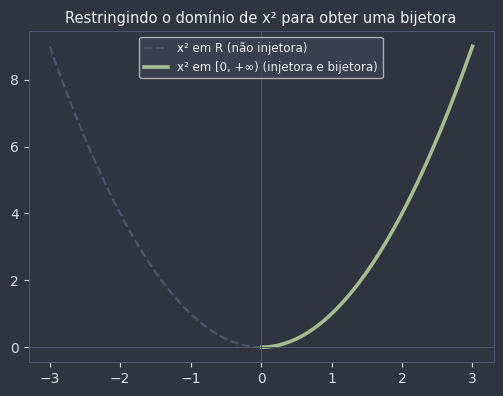

In [5]:
xs_restr = np.linspace(-3, 3, 300)
xs_restr_pos = xs_restr[xs_restr >= 0]

fig, ax = plt.subplots(figsize=(6, 4.3))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(
    xs_restr, xs_restr**2, color=NORD_LINHA, linewidth=1.6, linestyle="--",
    label="x² em R (não injetora)",
)
ax.plot(
    xs_restr_pos, xs_restr_pos**2, color=COR_DESTAQUE, linewidth=2.6,
    label="x² em [0, +∞) (injetora e bijetora)",
)
ax.axhline(0, color=NORD_LINHA, linewidth=0.7)
ax.axvline(0, color=NORD_LINHA, linewidth=0.7)
ax.set_title("Restringindo o domínio de x² para obter uma bijetora", color=NORD_TEXTO, fontsize=10.5)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8.5)
plt.show()

## Por que essa classificação importa

- A função **inversa** só existe (como função) quando a função original é **bijetora**. É exatamente esse o assunto do Bloco 5.

**Perguntas de checagem:**
1. Uma função pode ser sobrejetora e não ser injetora? Dê um exemplo.
2. Por que trocar o contradomínio pode transformar uma função não sobrejetora em sobrejetora, sem mexer na fórmula?

## Operações aritméticas entre funções

- 📌 **Definição formal:** dadas f e g,
    - (f+g)(x) = f(x) + g(x)
    - (f-g)(x) = f(x) - g(x)
    - (f·g)(x) = f(x) · g(x)
    - (f/g)(x) = f(x) / g(x)
- ⚠️ **Erro comum:** o domínio do resultado é a **interseção** dos domínios de f e g — e, no caso da divisão, ainda é preciso **excluir os pontos onde g(x) = 0**.

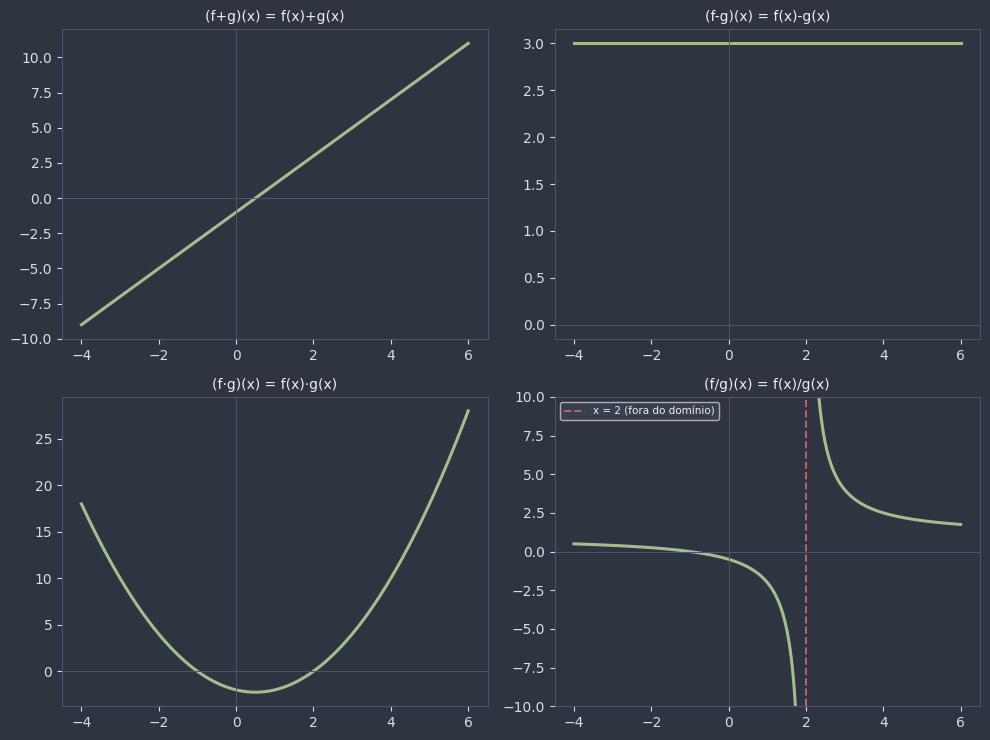

f(x) = x+1, g(x) = x-2
Domínio de (f+g), (f-g), (f·g): R (interseção dos domínios de f e g, que são R)
Domínio de (f/g): R - {2} (excluindo onde g(x) = 0)


In [6]:
def f_bloco4(x):
    return x + 1


def g_bloco4(x):
    return x - 2


xs_op = np.linspace(-4, 6, 400)
ponto_excluido = 2.0  # g(x) = 0 em x = 2 -> fora do domínio de f/g

fig, eixos = plt.subplots(2, 2, figsize=(10, 7.5))
fig.patch.set_facecolor(NORD_FUNDO)

operacoes = [
    ("(f+g)(x) = f(x)+g(x)", f_bloco4(xs_op) + g_bloco4(xs_op), False),
    ("(f-g)(x) = f(x)-g(x)", f_bloco4(xs_op) - g_bloco4(xs_op), False),
    ("(f·g)(x) = f(x)·g(x)", f_bloco4(xs_op) * g_bloco4(xs_op), False),
    ("(f/g)(x) = f(x)/g(x)", None, True),
]

for ax, (titulo, ys, eh_quociente) in zip(eixos.ravel(), operacoes):
    estilizar_eixo(ax)
    if eh_quociente:
        esquerda = xs_op[xs_op < ponto_excluido]
        direita = xs_op[xs_op > ponto_excluido]
        ax.plot(esquerda, f_bloco4(esquerda) / g_bloco4(esquerda), color=COR_DESTAQUE, linewidth=2.2)
        ax.plot(direita, f_bloco4(direita) / g_bloco4(direita), color=COR_DESTAQUE, linewidth=2.2)
        ax.axvline(
            ponto_excluido, color=COR_ALERTA, linewidth=1.4, linestyle="--",
            label=f"x = {ponto_excluido:g} (fora do domínio)",
        )
        ax.set_ylim(-10, 10)
        ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=7.5)
    else:
        ax.plot(xs_op, ys, color=COR_DESTAQUE, linewidth=2.2)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.7)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.7)
    ax.set_title(titulo, color=NORD_TEXTO, fontsize=10)

plt.tight_layout()
plt.show()

print("f(x) = x+1, g(x) = x-2")
print("Domínio de (f+g), (f-g), (f·g): R (interseção dos domínios de f e g, que são R)")
print(f"Domínio de (f/g): R - {{{ponto_excluido:g}}} (excluindo onde g(x) = 0)")

## Função composta

- 📌 **Definição formal:** (f∘g)(x) = f(g(x)) — aplica g primeiro, depois f no resultado.
- ⚠️ **Erro comum clássico:** g(f(x)) ≠ f(g(x)) em geral — **ordem importa**, composição não é comutativa.

Mova o slider x e acompanhe, passo a passo, o "caminho" do valor em (f∘g)(x) e em (g∘f)(x) — usando f(x) = x² e g(x) = x-1.

In [7]:
def f_comp(x):
    return x**2


def g_comp(x):
    return x - 1


xs_comp = np.linspace(-3, 4, 300)


def explorar_composta(x: float) -> None:
    passo_g = g_comp(x)
    fg = f_comp(passo_g)
    passo_f = f_comp(x)
    gf = g_comp(passo_f)

    print(f"(f∘g)(x) = f(g(x)):  x = {x:g}  ->  g(x) = {passo_g:g}  ->  f(g(x)) = {fg:g}")
    print(f"(g∘f)(x) = g(f(x)):  x = {x:g}  ->  f(x) = {passo_f:g}  ->  g(f(x)) = {gf:g}")
    print(f"Resultados iguais? {np.isclose(fg, gf)}")

    fig, ax = plt.subplots(figsize=(6.5, 4.3))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs_comp, f_comp(g_comp(xs_comp)), color=COR_DESTAQUE, linewidth=2.2, label="(f∘g)(x)")
    ax.plot(xs_comp, g_comp(f_comp(xs_comp)), color=COR_SECUNDARIA, linewidth=2.2, label="(g∘f)(x)")
    ax.scatter([x], [fg], s=110, color=COR_PONTO, zorder=3)
    ax.scatter([x], [gf], s=110, color=COR_ALERTA, zorder=3)
    ax.axvline(x, color=NORD_LINHA, linewidth=0.9, linestyle=":")
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=9)
    ax.set_title(f"f(x) = x², g(x) = x-1   (x = {x:g})", color=NORD_TEXTO, fontsize=10.5)
    plt.show()


widgets.interact(
    explorar_composta,
    x=widgets.FloatSlider(value=2.0, min=-3, max=4, step=0.5, description="x:"),
)

interactive(children=(FloatSlider(value=2.0, description='x:', max=4.0, min=-3.0, step=0.5), Output()), _dom_c…

<function __main__.explorar_composta(x: float) -> None>

## Domínio da composta

- O domínio de (f∘g)(x) é o conjunto dos x do domínio de g **tais que g(x) pertence ao domínio de f** — não basta olhar só o domínio de g.

**Perguntas de checagem:**
1. Dadas f(x) = x² e g(x) = x-1, calcule (f∘g)(2) e (g∘f)(2). Os resultados são iguais?
2. Por que o domínio de (f∘g)(x) depende também do domínio de f, e não só do de g?

## Função inversa

- 📌 **Definição formal:** f⁻¹ é a função que "desfaz" f — existe como função **se, e somente se, f é bijetora**.
- ⚠️ **Erro comum clássico:** confundir f⁻¹(x) com 1/f(x). São coisas completamente diferentes — a notação -1 aqui indica **função inversa**, não expoente/potência.

## Como encontrar a inversa algebricamente

Passo a passo:
1. Escreva y = f(x).
2. Troque x por y e y por x.
3. Isole y — o resultado é f⁻¹(x).

In [8]:
import sympy as sp

x_sym, y_sym = sp.symbols("x y")

f1_expr = 2 * x_sym + 3
f2_expr = x_sym**3

for nome, expr in [("f(x) = 2x+3", f1_expr), ("f(x) = x³", f2_expr)]:
    equacao = sp.Eq(y_sym, expr)
    solucao = sp.solve(equacao, x_sym)[0]
    inversa = solucao.subs(y_sym, x_sym)
    print(f"{nome}  ->  inversa: f⁻¹(x) = {inversa}")

f(x) = 2x+3  ->  inversa: f⁻¹(x) = x/2 - 3/2
f(x) = x³  ->  inversa: f⁻¹(x) = x**(1/3)


## Como verificar que duas funções são inversas uma da outra

- Retomando a composta do Bloco 4: f e g são inversas uma da outra se, e somente se, **f(g(x)) = x e g(f(x)) = x** para todo x do domínio correspondente. Esse é o teste definitivo, mais confiável do que "parece que desfaz".

## Relação gráfica entre f e f⁻¹

- O gráfico de f⁻¹ é o gráfico de f **refletido em relação à reta y = x**.

Mova o slider a e observe o ponto (a, f(a)) no gráfico de f e o ponto espelhado (f(a), a) no gráfico de f⁻¹ — os dois sempre simétricos em relação à reta y = x, desenhada como referência.

In [9]:
def f_inv_bloco5(x):
    return 2 * x + 3


def inversa_bloco5(x):
    return (x - 3) / 2


xs_inv = np.linspace(-6, 6, 300)


def explorar_inversa(a: float) -> None:
    ponto_f = (a, f_inv_bloco5(a))
    ponto_inv = (f_inv_bloco5(a), a)  # espelhado: (f(a), a)

    fig, ax = plt.subplots(figsize=(6, 6))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs_inv, f_inv_bloco5(xs_inv), color=COR_DESTAQUE, linewidth=2.2, label="f(x) = 2x+3")
    ax.plot(xs_inv, inversa_bloco5(xs_inv), color=COR_SECUNDARIA, linewidth=2.2, label="f⁻¹(x) = (x-3)/2")
    ax.plot(xs_inv, xs_inv, color=NORD_LINHA, linewidth=1.2, linestyle="--", label="y = x")
    ax.scatter(
        [ponto_f[0]], [ponto_f[1]], s=130, color=COR_PONTO, zorder=3,
        label=f"(a, f(a)) = ({ponto_f[0]:g}, {ponto_f[1]:g})",
    )
    ax.scatter(
        [ponto_inv[0]], [ponto_inv[1]], s=130, color=COR_ALERTA, zorder=3,
        label=f"(f(a), a) = ({ponto_inv[0]:g}, {ponto_inv[1]:g})",
    )
    ax.plot(
        [ponto_f[0], ponto_inv[0]], [ponto_f[1], ponto_inv[1]],
        color=NORD_TEXTO_SEC, linewidth=1, linestyle=":",
    )
    ax.set_xlim(-15, 15)
    ax.set_ylim(-15, 15)
    ax.set_aspect("equal")
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8, loc="upper left")
    ax.set_title("Reflexão de f e f⁻¹ em torno da reta y = x", color=NORD_TEXTO, fontsize=11)
    plt.show()

    print(f"f({a:g}) = {ponto_f[1]:g}   ->   ponto (a, f(a)) = {ponto_f}")
    print(f"f⁻¹(f({a:g})) = {inversa_bloco5(ponto_f[1]):g}   (volta para a, confirmando que desfaz f)")


widgets.interact(
    explorar_inversa,
    a=widgets.FloatSlider(value=1.0, min=-6, max=6, step=0.5, description="a:"),
)

interactive(children=(FloatSlider(value=1.0, description='a:', max=6.0, min=-6.0, step=0.5), Output()), _dom_c…

<function __main__.explorar_inversa(a: float) -> None>

**Perguntas de checagem:**
1. Por que uma função que não é injetora não pode ter inversa (como função)?
2. Se f(g(x)) = x mas g(f(x)) ≠ x, g pode ser considerada a inversa de f?

## Resumo

- **Crescente / decrescente / constante:** classificação **por intervalo** (x1 < x2 ⟹ f(x1) < f(x2), f(x1) > f(x2) ou f(x1) = f(x2), respectivamente).
- **Par:** f(-x) = f(x), simetria em relação ao eixo y. **Ímpar:** f(-x) = -f(x), simetria em relação à origem. Nem toda função é uma coisa ou outra.
- **Injetora:** teste da reta horizontal (no máximo uma interseção). **Sobrejetora:** imagem = contradomínio (depende do contradomínio escolhido). **Bijetora:** injetora e sobrejetora ao mesmo tempo.
- Restringir o domínio de uma função pode torná-la injetora (e, ajustando o contradomínio, bijetora) — base das funções trigonométricas inversas.
- **Operações:** (f±g)(x), (f·g)(x), (f/g)(x) — domínio = interseção dos domínios, com cuidado extra na divisão (excluir zeros de g).
- **Composta:** (f∘g)(x) = f(g(x)) — ordem importa; domínio depende do domínio de g **e** do domínio de f.
- **Inversa:** existe só se f é bijetora; f⁻¹(x) ≠ 1/f(x); teste definitivo é f(g(x))=x e g(f(x))=x; gráfico de f⁻¹ é o de f refletido em relação a y = x.

## Exercícios

**Básico**
1. Observar o gráfico de `temperatura(x)` (Bloco 1) e identificar os intervalos de crescimento e decrescimento.
2. Classificar funções simples dadas por fórmula (x², x³, x²+x) em par, ímpar ou nenhuma das duas.

**Intermediário**
1. Aplicar o teste da reta horizontal em quatro gráficos e classificar cada um como injetora e/ou sobrejetora (contradomínio declarado = R).
2. Calcular (f+g)(x), (f·g)(x) e (f/g)(x) para f(x)=x+1 e g(x)=x-2, indicando o domínio de cada resultado.

**Desafio**
1. Dadas f(x) = 2x-1 e g(x) = x+3, calcular (f∘g)(x) e (g∘f)(x) e mostrar que são diferentes.
2. Encontrar algebricamente a inversa de f(x) = (x+1)/(x-2) e verificar o resultado calculando f(f⁻¹(x)) e f⁻¹(f(x)).

### Básico

In [ ]:
# Exercício Básico 1: observando o gráfico de temperatura(x) do Bloco 1, em
# que intervalo (a, b) a função é crescente? E decrescente?
intervalo_crescente_ex = ...  # tupla (a, b)
intervalo_decrescente_ex = ...  # tupla (a, b)

print(intervalo_crescente_ex, intervalo_decrescente_ex)

In [ ]:
# Verificação
assert intervalo_crescente_ex == (0, 4), (
    "Tente de novo, revise o passo 1: a temperatura sobe de x=0 até x=4."
)
assert intervalo_decrescente_ex == (8, 14), (
    "Tente de novo, revise o passo 1: a temperatura cai de x=8 até x=14."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: classifique em par, ímpar ou nenhuma das duas
def h1(x):
    return x**2


def h2(x):
    return x**3


classificacao_h1 = ...
classificacao_h2 = ...
classificacao_h3 = ...  # dica: use funcao_nem_par_nem_impar, definida no Bloco 2

print(classificacao_h1, classificacao_h2, classificacao_h3)

In [ ]:
# Verificação
assert classificacao_h1 == classificar_paridade(h1), (
    "Tente de novo, revise o passo 1: use classificar_paridade(h1)."
)
assert classificacao_h2 == classificar_paridade(h2), (
    "Tente de novo, revise o passo 1: use classificar_paridade(h2)."
)
assert classificacao_h3 == classificar_paridade(funcao_nem_par_nem_impar), (
    "Tente de novo, revise o passo 1: use classificar_paridade(funcao_nem_par_nem_impar)."
)
assert (classificacao_h1, classificacao_h2, classificacao_h3) == ("par", "impar", "nenhuma"), (
    "Confira: h1(x)=x² é par, h2(x)=x³ é ímpar, e x²+x não é nem par nem ímpar."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 1: observe os quatro gráficos e classifique cada
# função como (injetora, sobrejetora) -- tupla de bool -- contradomínio = R
def p1(x):
    return np.sin(x)


def p2(x):
    return x**3 - x


def p3(x):
    return np.abs(x)


def p4(x):
    return x**3


xs_int1 = np.linspace(-4, 4, 400)
fig, eixos = plt.subplots(1, 4, figsize=(15, 3.6))
fig.patch.set_facecolor(NORD_FUNDO)
for eixo, f, nome in zip(eixos, [p1, p2, p3, p4], ["sen(x)", "x³-x", "|x|", "x³"]):
    estilizar_eixo(eixo)
    eixo.plot(xs_int1, f(xs_int1), color=COR_DESTAQUE, linewidth=2)
    eixo.axhline(0, color=NORD_LINHA, linewidth=0.7)
    eixo.axvline(0, color=NORD_LINHA, linewidth=0.7)
    eixo.set_title(nome, color=NORD_TEXTO, fontsize=10)
plt.tight_layout()
plt.show()

classificacao_p1 = ...  # sen(x)
classificacao_p2 = ...  # x^3 - x
classificacao_p3 = ...  # |x|
classificacao_p4 = ...  # x^3

print(classificacao_p1, classificacao_p2, classificacao_p3, classificacao_p4)

In [ ]:
# Verificação
assert classificacao_p1 == (False, False), (
    "Tente de novo: sen(x) repete valores (não injetora) e a imagem é [-1,1], "
    "não cobre todo R (não sobrejetora)."
)
assert classificacao_p2 == (False, True), (
    "Tente de novo: x³-x tem f(-1)=f(0)=f(1)=0 (não injetora), mas por ser "
    "polinômio de grau ímpar cobre todo R (sobrejetora)."
)
assert classificacao_p3 == (False, False), (
    "Tente de novo: |x| repete valores (|a|=|-a|, não injetora) e a imagem é "
    "[0,+∞), não cobre todo R (não sobrejetora)."
)
assert classificacao_p4 == (True, True), (
    "Tente de novo: x³ é estritamente crescente (injetora) e cobre todo R (sobrejetora)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 2: use sympy para calcular (f+g)(x), (f.g)(x) e
# (f/g)(x) para f(x)=x+1 e g(x)=x-2, e o domínio de (f/g)
f_int2 = x_sym + 1
g_int2 = x_sym - 2

soma_ex = ...       # dica: f_int2 + g_int2
produto_ex = ...    # dica: f_int2 * g_int2
quociente_ex = ...  # dica: f_int2 / g_int2
dominio_quociente_ex = ...  # dica: sp.calculus.util.continuous_domain(quociente_ex, x_sym, sp.S.Reals)

print(soma_ex, produto_ex, quociente_ex, dominio_quociente_ex)

In [ ]:
# Verificação
assert sp.simplify(soma_ex - (f_int2 + g_int2)) == 0, (
    "Tente de novo, revise o passo 1: some f_int2 + g_int2."
)
assert sp.simplify(produto_ex - (f_int2 * g_int2)) == 0, (
    "Tente de novo, revise o passo 1: multiplique f_int2 * g_int2."
)
assert sp.simplify(quociente_ex - (f_int2 / g_int2)) == 0, (
    "Tente de novo, revise o passo 1: divida f_int2 / g_int2."
)
esperado_dominio = sp.calculus.util.continuous_domain(quociente_ex, x_sym, sp.S.Reals)
assert dominio_quociente_ex == esperado_dominio, (
    "Tente de novo, revise o passo 1: o denominador g(x)=x-2 não pode ser zero."
)
assert dominio_quociente_ex == sp.S.Reals - sp.FiniteSet(2), (
    "Confira: x-2 != 0 -> x != 2, então o domínio de (f/g) é R - {2}."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 1: f(x) = 2x-1 e g(x) = x+3 -- calcule (f o g)(x) e
# (g o f)(x) usando sympy e mostre que são diferentes
f_des1 = 2 * x_sym - 1
g_des1 = x_sym + 3

fg_composta_ex = ...  # dica: f_des1.subs(x_sym, g_des1)
gf_composta_ex = ...  # dica: g_des1.subs(x_sym, f_des1)

print(sp.expand(fg_composta_ex), sp.expand(gf_composta_ex))

In [ ]:
# Verificação
esperado_fg = sp.expand(f_des1.subs(x_sym, g_des1))
esperado_gf = sp.expand(g_des1.subs(x_sym, f_des1))
assert sp.expand(fg_composta_ex) == esperado_fg, (
    "Tente de novo, revise o passo 1: substitua g_des1 no lugar de x em f_des1."
)
assert sp.expand(gf_composta_ex) == esperado_gf, (
    "Tente de novo, revise o passo 1: substitua f_des1 no lugar de x em g_des1."
)
assert sp.expand(fg_composta_ex) != sp.expand(gf_composta_ex), (
    "Confira: (f∘g)(x) = 2x+5 e (g∘f)(x) = 2x+2 são expressões diferentes."
)
print("Certo!")

In [ ]:
# Exercício Desafio 2: encontre a inversa de f(x) = (x+1)/(x-2) e verifique
# f(f-1(x)) = x e f-1(f(x)) = x
f_des2 = (x_sym + 1) / (x_sym - 2)

inversa_des2 = ...  # dica: sp.solve(sp.Eq(y_sym, f_des2), x_sym)[0].subs(y_sym, x_sym)

verificacao_1 = ...  # dica: f_des2.subs(x_sym, inversa_des2)
verificacao_2 = ...  # dica: inversa_des2.subs(x_sym, f_des2)

print(inversa_des2)
print(sp.simplify(verificacao_1), sp.simplify(verificacao_2))

In [ ]:
# Verificação
esperado_inversa = sp.solve(sp.Eq(y_sym, f_des2), x_sym)[0].subs(y_sym, x_sym)
assert sp.simplify(inversa_des2 - esperado_inversa) == 0, (
    "Tente de novo, revise o passo 1: isole x em y=(x+1)/(x-2) e troque y por x no final."
)
assert sp.simplify(verificacao_1 - x_sym) == 0, (
    "Tente de novo, revise o passo 2: calcule f_des2 com x_sym substituído por inversa_des2."
)
assert sp.simplify(verificacao_2 - x_sym) == 0, (
    "Tente de novo, revise o passo 2: calcule inversa_des2 com x_sym substituído por f_des2."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0105a_funcoes.ipynb`](0105a_funcoes.ipynb) (conceito, notação, domínio/contradomínio/imagem, gráfico, funções iguais)
- [`0102a_conjuntos.ipynb`](0102a_conjuntos.ipynb) (relação entre conjuntos, pares ordenados)

**Isso será usado em:**
- [`05_trigonometria/`](../05_trigonometria/) (funções trigonométricas inversas dependem diretamente da ideia de restringir o domínio para obter bijetora)
- Função de 1º e 2º Grau (crescimento/decrescimento reaparece no estudo do sinal e no vértice da parábola)
- [`11_limite_integral_e_derivada/`](../11_limite_integral_e_derivada/) (crescimento/decrescimento por intervalo é a base intuitiva para máximos e mínimos)
- Praticamente todo o restante do curso, sempre que duas funções precisarem ser combinadas ou revertidas